# Anomaly Detection in IoT Data — Data Exploration

This notebook downloads the open-source Numenta Anomaly Benchmark (NAB) time-series data, inspects the sensor signal, and prepares a clean view for the autoencoder workflow.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)

NORMAL_URL = "https://raw.githubusercontent.com/numenta/NAB/master/data/artificialNoAnomaly/art_daily_small_noise.csv"
ANOMALY_URL = "https://raw.githubusercontent.com/numenta/NAB/master/data/artificialWithAnomaly/art_daily_jumpsup.csv"

## Load the data

The normal series is used as the reference behavior. The second series contains unusual changes and is reserved for testing.

In [2]:
normal = pd.read_csv(NORMAL_URL, parse_dates=["timestamp"])
anomalous = pd.read_csv(ANOMALY_URL, parse_dates=["timestamp"])

normal.head()

,timestamp,value
0,2014-04-01 00:00:00,18.324919
1,2014-04-01 00:05:00,21.970327
2,2014-04-01 00:10:00,18.624806
3,2014-04-01 00:15:00,21.953684
4,2014-04-01 00:20:00,21.909120


In [4]:
print("Normal rows:", len(normal))
print("Test rows:", len(anomalous))
print("Normal columns:", normal.columns.tolist())
print("Missing values:\n", normal.isna().sum())


Normal rows: 4032
Test rows: 4032
Normal columns: ['timestamp', 'value']
Missing values:
 timestamp    0
value        0
dtype: int64


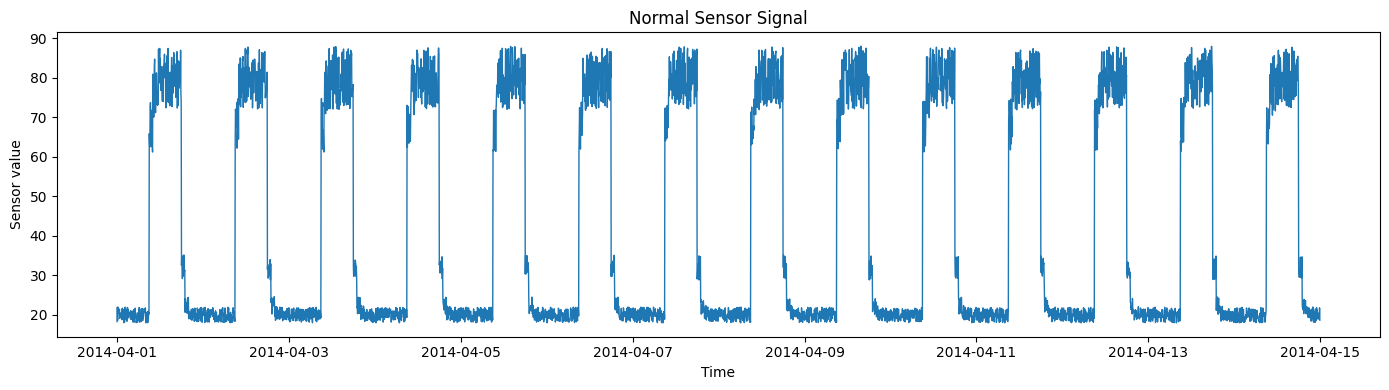

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(normal["timestamp"], normal["value"], linewidth=1)
ax.set_title("Normal Sensor Signal")
ax.set_xlabel("Time")
ax.set_ylabel("Sensor value")
plt.tight_layout()
plt.show()

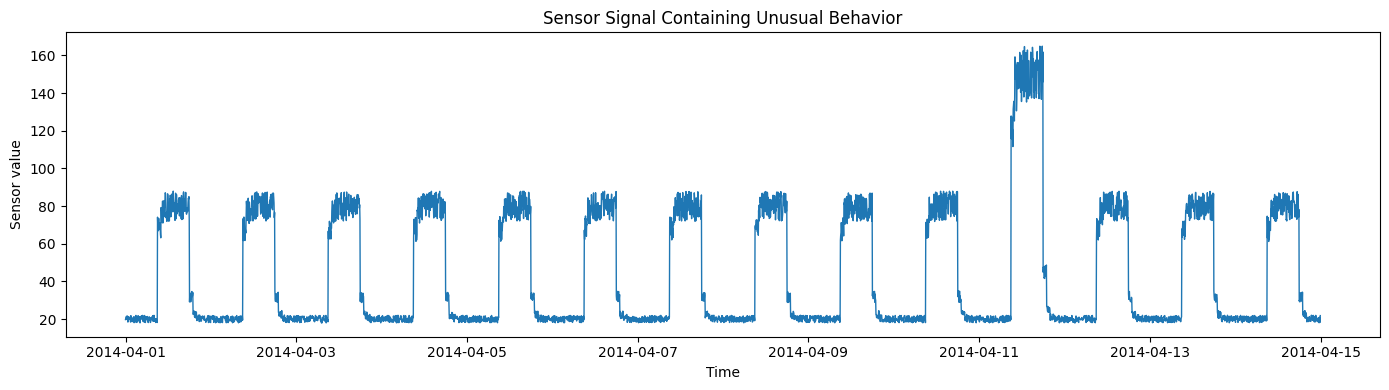

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(anomalous["timestamp"], anomalous["value"], linewidth=1)
ax.set_title("Sensor Signal Containing Unusual Behavior")
ax.set_xlabel("Time")
ax.set_ylabel("Sensor value")
plt.tight_layout()
plt.show()

## Basic statistics

A useful first check is the difference between the distribution of the normal training signal and the test signal.

In [7]:
summary = pd.DataFrame({
    "normal": normal["value"].describe(),
    "test": anomalous["value"].describe()
})
summary

,normal,test
count,4032.000000,4032.000000
mean,42.438353,44.494254
std,28.077122,32.432473
min,18.000964,18.001010
25%,19.841390,19.991382
50%,21.608487,21.648503
75%,75.450282,76.435943
max,87.976128,164.947481


## Training idea

The autoencoder will learn normal windows rather than learning an anomaly class. During inference, a window that cannot be reconstructed well receives a large reconstruction error. This is the anomaly score.

In [8]:
TRAIN_MEAN = normal["value"].mean()
TRAIN_STD = normal["value"].std()

print(f"Training mean: {TRAIN_MEAN:.4f}")
print(f"Training standard deviation: {TRAIN_STD:.4f}")

Training mean: 42.4384
Training standard deviation: 28.0771
